In [2]:
"""
================================================================
  LSTM vs GRU — Understanding Sequence Models
  Dataset : Monthly Temperature Data (something everyone knows!)
  Audience: Freshers / Beginners
  Task    : Predict next month's temperature from past months
================================================================

WHY TEMPERATURE?
  Everyone has experienced seasons. Temperatures follow a clear
  pattern (summer→autumn→winter→spring) — which makes it easy to
  understand WHY a model needs MEMORY to predict the next value.

  "If it was cold for the past 3 months, next month will probably
   still be cold." ← This is exactly what LSTM/GRU learn!
"""

# ── IMPORTS ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.15.0


In [3]:
# ==============================================================================
# SECTION 1 — THE INTUITION (Read this before touching any code!)
# ==============================================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║             THE CORE IDEA — WHY DO WE NEED LSTM/GRU?        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Normal Neural Net:  Input → Output  (no memory)            ║
║  Each prediction is INDEPENDENT of previous ones.           ║
║                                                              ║
║  RNN (basic):  Has memory, but FORGETS things far back.      ║
║  Like trying to remember a lecture from 3 weeks ago.         ║
║                                                              ║
║  LSTM (Long Short-Term Memory):                              ║
║    Has a "notebook" (cell state) to write/erase/read info.   ║
║    Can remember patterns from LONG ago.                      ║
║    Uses 3 gates: Forget | Input | Output                     ║
║                                                              ║
║  GRU (Gated Recurrent Unit):                                 ║
║    Simpler version of LSTM — fewer parameters.               ║
║    Uses 2 gates: Reset | Update                              ║
║    Often performs similarly to LSTM but trains faster.       ║
║                                                              ║
╚══════════════════════════════════════════════════════════════╝
""")



╔══════════════════════════════════════════════════════════════╗
║             THE CORE IDEA — WHY DO WE NEED LSTM/GRU?        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  Normal Neural Net:  Input → Output  (no memory)            ║
║  Each prediction is INDEPENDENT of previous ones.           ║
║                                                              ║
║  RNN (basic):  Has memory, but FORGETS things far back.      ║
║  Like trying to remember a lecture from 3 weeks ago.         ║
║                                                              ║
║  LSTM (Long Short-Term Memory):                              ║
║    Has a "notebook" (cell state) to write/erase/read info.   ║
║    Can remember patterns from LONG ago.                      ║
║    Uses 3 gates: Forget | Input | Output                     ║
║                                                              ║
║  GRU (Gated Recurrent Uni

SECTION 2: Creating Monthly Temperature Dataset


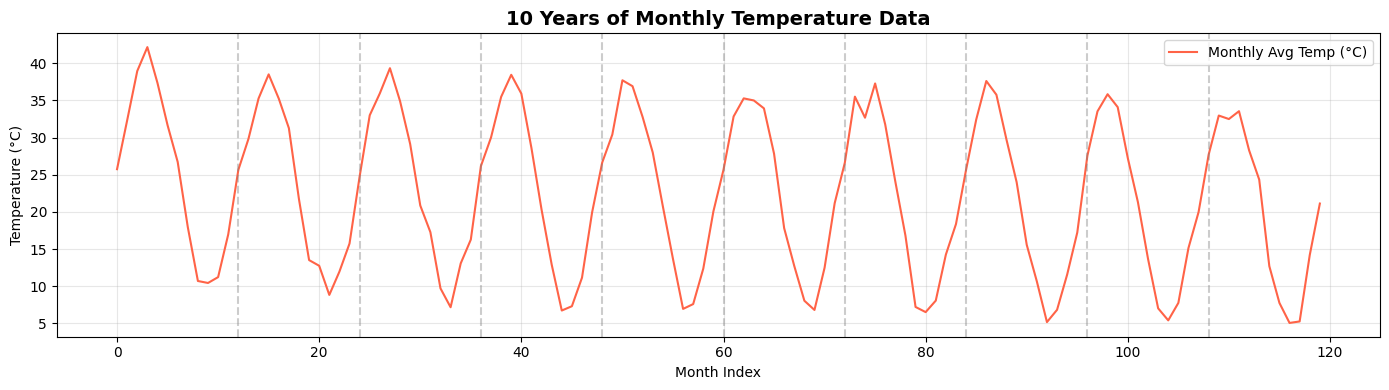

  ✅ Saved: temperature_dataset.png

  Dataset Summary:
    Total months   : 120
    Min temperature: 5.1°C
    Max temperature: 42.2°C
    Avg temperature: 22.4°C



In [4]:


# ==============================================================================
# SECTION 2 — CREATE A RELATABLE DATASET: Monthly Temperatures
# ==============================================================================
print("=" * 60)
print("SECTION 2: Creating Monthly Temperature Dataset")
print("=" * 60)

# --- Simulate 10 years of monthly average temperatures (°C) ---
# Pattern: seasonal sine wave + small random noise
# This mimics a city like New Delhi (hot summers, cool winters)

months_per_year = 12
num_years       = 10
total_months    = months_per_year * num_years   # 120 data points

# Time axis: 0 to 10 years in monthly steps
t = np.linspace(0, num_years, total_months)

# Base temperature pattern:
#   - Annual sine wave  (period = 1 year) → captures seasons
#   - Slight upward trend                 → mimics climate change
#   - Random noise                        → real-world messiness
temperature = (
    25                               # average base temperature
    + 15 * np.sin(2 * np.pi * t)     # seasonal swing ±15°C
    - 0.5 * t                         # slight cooling trend over time
    + np.random.normal(0, 1.5, total_months)  # noise
).astype("float32")

# Month names for nice plotting
month_names = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

# --- Plot the raw dataset ---
plt.figure(figsize=(14, 4))
plt.plot(temperature, color="tomato", linewidth=1.5, label="Monthly Avg Temp (°C)")
plt.title("10 Years of Monthly Temperature Data", fontsize=14, fontweight="bold")
plt.xlabel("Month Index")
plt.ylabel("Temperature (°C)")
# Mark year boundaries
for yr in range(1, num_years):
    plt.axvline(x=yr * 12, color="gray", linestyle="--", alpha=0.4)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("temperature_dataset.png", dpi=150)
plt.show()
print("  ✅ Saved: temperature_dataset.png")

print(f"""
  Dataset Summary:
    Total months   : {total_months}
    Min temperature: {temperature.min():.1f}°C
    Max temperature: {temperature.max():.1f}°C
    Avg temperature: {temperature.mean():.1f}°C
""")



In [5]:
# ==============================================================================
# SECTION 3 — PREPARE DATA FOR SEQUENCE MODELS
# ==============================================================================
print("=" * 60)
print("SECTION 3: Preparing Sequences (Sliding Window)")
print("=" * 60)

"""
CONCEPT: Sliding Window
────────────────────────
We can't just feed raw temperatures to LSTM/GRU.
We need to create (input_sequence → target) pairs.

  LOOK_BACK = 12  means:
  "Given the last 12 months of temperatures,
   predict the temperature of the NEXT month."

  Example (LOOK_BACK=3 for simplicity):
    [Jan, Feb, Mar] → predict Apr
    [Feb, Mar, Apr] → predict May
    [Mar, Apr, May] → predict Jun
    ...and so on (the window SLIDES forward each time)

  Shape of X : (num_samples, LOOK_BACK, 1)
               ↑ samples   ↑ time steps ↑ features
  Shape of y : (num_samples,)
"""

LOOK_BACK = 12   # Use 1 full year of history to predict next month

def create_sequences(data, look_back):
    """Convert a 1-D time series into (X, y) pairs using sliding window."""
    X, y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i : i + look_back])   # window of past values
        y.append(data[i + look_back])        # next value to predict
    return np.array(X), np.array(y)

# --- Normalise temperatures to [0, 1] ---
# Neural networks train better when inputs are small numbers.
temp_min = temperature.min()
temp_max = temperature.max()
temp_norm = (temperature - temp_min) / (temp_max - temp_min)

# --- Create sequences ---
X, y = create_sequences(temp_norm, LOOK_BACK)

# LSTM/GRU expect shape: (samples, timesteps, features)
# We have 1 feature (temperature), so we add a last dimension.
X = X.reshape(X.shape[0], X.shape[1], 1)

print(f"  X shape : {X.shape}  → (samples, timesteps, features)")
print(f"  y shape : {y.shape}  → (samples,)")

# --- Train / Test split (80/20) ---
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\n  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")

SECTION 3: Preparing Sequences (Sliding Window)
  X shape : (108, 12, 1)  → (samples, timesteps, features)
  y shape : (108,)  → (samples,)

  Training samples : 86
  Testing  samples : 22


In [6]:
# ==============================================================================
# SECTION 4 — BUILD LSTM MODEL
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 4: LSTM Model")
print("=" * 60)

"""
LSTM LAYER EXPLAINED:
─────────────────────
  keras.layers.LSTM(units=64)

  ┌─────────────────────────────────────────────┐
  │  At each time step, the LSTM cell receives:  │
  │   • Current input  (this month's temp)       │
  │   • Hidden state   (short-term memory)       │
  │   • Cell state     (long-term memory)        │
  │                                              │
  │  It uses 3 GATES to decide:                  │
  │   🔴 FORGET GATE : what to erase from memory │
  │   🟢 INPUT  GATE : what new info to store    │
  │   🔵 OUTPUT GATE : what to output now        │
  └─────────────────────────────────────────────┘

  return_sequences=False → only return the LAST output
  (we only need 1 prediction, not one per time step)
"""

def build_lstm_model():
    model = keras.Sequential(name="LSTM_Model")

    # Input shape: (timesteps=12, features=1)
    model.add(layers.Input(shape=(LOOK_BACK, 1)))

    # First LSTM layer — learns patterns in the sequence
    # return_sequences=True because we stack another LSTM on top
    model.add(layers.LSTM(64, return_sequences=True,
                          name="LSTM_layer_1"))

    # Second LSTM layer — learns higher-level patterns
    # return_sequences=False because this is the last LSTM layer
    model.add(layers.LSTM(32, return_sequences=False,
                          name="LSTM_layer_2"))

    # Dropout to prevent overfitting
    model.add(layers.Dropout(0.2, name="dropout"))

    # Dense output layer — outputs a single temperature prediction
    model.add(layers.Dense(1, name="output"))

    return model

lstm_model = build_lstm_model()
lstm_model.summary()

lstm_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",            # Mean Squared Error — common for regression
    metrics=["mae"],       # Mean Absolute Error — easy to interpret (°C)
)

print("\n  Training LSTM model ...")
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=8,
               restore_best_weights=True, verbose=0)],
    verbose=0,
)
print("  ✅ LSTM training complete!")




SECTION 4: LSTM Model
Model: "LSTM_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 LSTM_layer_1 (LSTM)         (None, 12, 64)            16896     
                                                                 
 LSTM_layer_2 (LSTM)         (None, 32)                12416     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 output (Dense)              (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

  Training LSTM model ...
  ✅ LSTM training complete!


In [8]:
# ==============================================================================
# SECTION 5 — BUILD GRU MODEL
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 5: GRU Model")
print("=" * 60)

"""
GRU LAYER EXPLAINED:
──────────────────────
  keras.layers.GRU(units=64)

  GRU is a SIMPLIFIED version of LSTM.
  It merges the cell state & hidden state into ONE.
  It uses only 2 GATES:

   🔵 UPDATE GATE : how much of the old memory to keep
   🟠 RESET  GATE : how much of the past to forget

  GRU has FEWER parameters than LSTM
  → trains FASTER
  → often similar accuracy on small datasets

  ANALOGY:
    LSTM = Full notebook (write, erase, read separately)
    GRU  = Sticky notes  (simpler, fewer steps, still works great!)
"""

def build_gru_model():
    model = keras.Sequential(name="GRU_Model")

    model.add(layers.Input(shape=(LOOK_BACK, 1)))

    # First GRU layer
    model.add(layers.GRU(64, return_sequences=True,
                         name="GRU_layer_1"))

    # Second GRU layer
    model.add(layers.GRU(32, return_sequences=False,
                         name="GRU_layer_2"))

    model.add(layers.Dropout(0.2, name="dropout"))

    model.add(layers.Dense(1, name="output"))

    return model

gru_model = build_gru_model()
gru_model.summary()

gru_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

print("\n  Training GRU model ...")
gru_history = gru_model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=50,
    batch_size=16,
    callbacks=[keras.callbacks.EarlyStopping(patience=8,
               restore_best_weights=True, verbose=0)],
    verbose=0,
)
print("  GRU training complete!")




SECTION 5: GRU Model
Model: "GRU_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 GRU_layer_1 (GRU)           (None, 12, 64)            12864     
                                                                 
 GRU_layer_2 (GRU)           (None, 32)                9408      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 output (Dense)              (None, 1)                 33        
                                                                 
Total params: 22305 (87.13 KB)
Trainable params: 22305 (87.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________

  Training GRU model ...
  GRU training complete!



SECTION 6: Comparing Training Curves


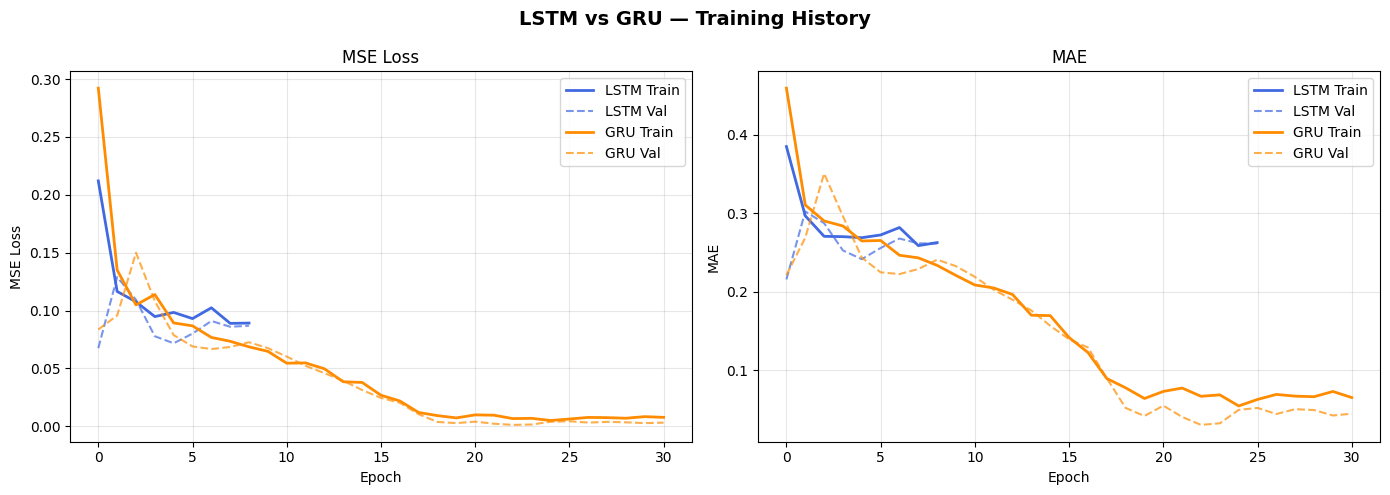

   Saved: training_curves.png


In [9]:
# ==============================================================================
# SECTION 6 — COMPARE TRAINING CURVES
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 6: Comparing Training Curves")
print("=" * 60)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("LSTM vs GRU — Training History", fontsize=14, fontweight="bold")

for ax, metric, title in zip(axes, ["loss", "mae"], ["MSE Loss", "MAE"]):
    ax.plot(lstm_history.history[metric],
            label="LSTM Train", color="royalblue", linewidth=2)
    ax.plot(lstm_history.history[f"val_{metric}"],
            label="LSTM Val", color="royalblue", linestyle="--", alpha=0.7)
    ax.plot(gru_history.history[metric],
            label="GRU Train", color="darkorange", linewidth=2)
    ax.plot(gru_history.history[f"val_{metric}"],
            label="GRU Val", color="darkorange", linestyle="--", alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("   Saved: training_curves.png")




SECTION 7: Predictions on Test Set


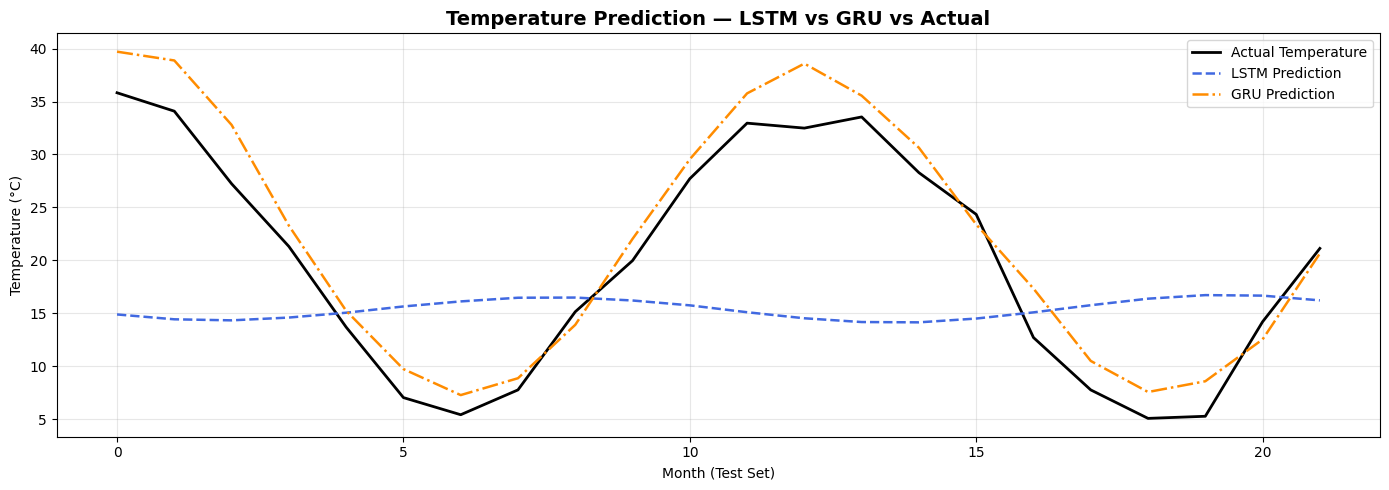

   Saved: predictions.png


In [10]:
# ==============================================================================
# SECTION 7 — MAKE PREDICTIONS & VISUALISE
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 7: Predictions on Test Set")
print("=" * 60)

# --- Get predictions (still in normalised scale) ---
lstm_pred_norm = lstm_model.predict(X_test, verbose=0).flatten()
gru_pred_norm  = gru_model.predict(X_test,  verbose=0).flatten()

# --- Rescale back to °C ---
def rescale(values):
    return values * (temp_max - temp_min) + temp_min

y_test_actual = rescale(y_test)
lstm_pred     = rescale(lstm_pred_norm)
gru_pred      = rescale(gru_pred_norm)

# --- Plot predictions vs actual ---
plt.figure(figsize=(14, 5))
x_axis = np.arange(len(y_test_actual))

plt.plot(x_axis, y_test_actual, label="Actual Temperature",
         color="black", linewidth=2)
plt.plot(x_axis, lstm_pred, label="LSTM Prediction",
         color="royalblue", linewidth=1.8, linestyle="--")
plt.plot(x_axis, gru_pred,  label="GRU Prediction",
         color="darkorange", linewidth=1.8, linestyle="-.")

plt.title("Temperature Prediction — LSTM vs GRU vs Actual",
          fontsize=14, fontweight="bold")
plt.xlabel("Month (Test Set)")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("predictions.png", dpi=150)
plt.show()
print("   Saved: predictions.png")


In [11]:
# ==============================================================================
# SECTION 8 — EVALUATE & COMPARE MODELS
# ==============================================================================
print("\n" + "=" * 60)
print("SECTION 8: Model Evaluation")
print("=" * 60)

lstm_mae = np.mean(np.abs(y_test_actual - lstm_pred))
gru_mae  = np.mean(np.abs(y_test_actual - gru_pred))

lstm_params = lstm_model.count_params()
gru_params  = gru_model.count_params()

print(f"""
  ┌─────────────────────────────────────────────┐
  │         LSTM vs GRU — Final Comparison      │
  ├──────────────────┬──────────────┬───────────┤
  │ Metric           │     LSTM     │    GRU    │
  ├──────────────────┼──────────────┼───────────┤
  │ Test MAE (°C)    │  {lstm_mae:>8.2f}    │ {gru_mae:>7.2f}   │
  │ Total Parameters │  {lstm_params:>8,}    │ {gru_params:>7,}   │
  ├──────────────────┴──────────────┴───────────┤
  │ Lower MAE = better predictions               │
  │ Fewer params = faster to train               │
  └─────────────────────────────────────────────┘
""")




SECTION 8: Model Evaluation

  ┌─────────────────────────────────────────────┐
  │         LSTM vs GRU — Final Comparison      │
  ├──────────────────┬──────────────┬───────────┤
  │ Metric           │     LSTM     │    GRU    │
  ├──────────────────┼──────────────┼───────────┤
  │ Test MAE (°C)    │     10.29    │    2.64   │
  │ Total Parameters │    29,345    │  22,305   │
  ├──────────────────┴──────────────┴───────────┤
  │ Lower MAE = better predictions               │
  │ Fewer params = faster to train               │
  └─────────────────────────────────────────────┘



In [12]:

# ==============================================================================
# SECTION 9 — PREDICT THE NEXT UNSEEN MONTH (Fun Demo!)
# ==============================================================================
print("=" * 60)
print("SECTION 9: Predict the NEXT Month (Unseen Future!)")
print("=" * 60)

"""
This is the FUN part — let's use the models to predict a
month that doesn't exist in our dataset at all!

We take the LAST 12 months from our data as input
and ask both LSTM and GRU: "What comes next?"
"""

# Take the last LOOK_BACK months from the entire dataset
last_window      = temp_norm[-LOOK_BACK:]
last_window_in   = last_window.reshape(1, LOOK_BACK, 1)

lstm_next_norm = lstm_model.predict(last_window_in, verbose=0)[0][0]
gru_next_norm  = gru_model.predict(last_window_in,  verbose=0)[0][0]

lstm_next = rescale(lstm_next_norm)
gru_next  = rescale(gru_next_norm)

# Which month would this be?
next_month_index = total_months % months_per_year
next_month_name  = month_names[next_month_index]

print(f"""
  Last known month  : {month_names[(total_months - 1) % 12]}
  Predicting month  : {next_month_name}

  LSTM predicts     : {lstm_next:.1f} °C
  GRU  predicts     : {gru_next:.1f} °C

  (Both should be close to each other and make seasonal sense!)
""")



SECTION 9: Predict the NEXT Month (Unseen Future!)

  Last known month  : Dec
  Predicting month  : Jan

  LSTM predicts     : 15.6 °C
  GRU  predicts     : 29.6 °C

  (Both should be close to each other and make seasonal sense!)



In [13]:

# ==============================================================================
# SECTION 10 — CHEAT SHEET
# ==============================================================================
print("""
╔══════════════════════════════════════════════════════════════╗
║            LSTM vs GRU — QUICK REFERENCE CARD               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  LSTM (Long Short-Term Memory)                               ║
║  ──────────────────────────────────────────────────────────  ║
║  • Has 3 gates  : Forget | Input | Output                    ║
║  • Maintains TWO states: hidden state + cell state           ║
║  • Good for long sequences where distant past matters        ║
║  • More parameters → slower to train                         ║
║  • Code: layers.LSTM(units, return_sequences=True/False)     ║
║                                                              ║
║  GRU (Gated Recurrent Unit)                                  ║
║  ──────────────────────────────────────────────────────────  ║
║  • Has 2 gates  : Reset | Update                             ║
║  • Maintains ONE state: hidden state only                    ║
║  • Good default choice — simpler & faster than LSTM          ║
║  • Fewer parameters → trains faster                          ║
║  • Code: layers.GRU(units, return_sequences=True/False)      ║
║                                                              ║
║  KEY PARAMETERS                                              ║
║  ──────────────────────────────────────────────────────────  ║
║  units             → memory size (more = learns more)        ║
║  return_sequences  → True if more LSTM/GRU layers follow     ║
║                      False for the last recurrent layer      ║
║                                                              ║
║  WHEN TO USE WHAT?                                           ║
║  ──────────────────────────────────────────────────────────  ║
║  Both unknown?       → Start with GRU (simpler, faster)      ║
║  Very long sequences → LSTM might help (longer memory)       ║
║  Limited compute?    → GRU (fewer params)                    ║
║  Best accuracy?      → Try both, compare on validation set   ║
║                                                              ║
║  COMMON USE CASES                                            ║
║  ──────────────────────────────────────────────────────────  ║
║  📈 Time series forecasting  (stock prices, weather, sales)  ║
║  📝 Text generation / NLP    (autocomplete, translation)     ║
║  🎵 Music generation                                         ║
║  🔍 Anomaly detection        (fraud, sensor data)            ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║            LSTM vs GRU — QUICK REFERENCE CARD               ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  LSTM (Long Short-Term Memory)                               ║
║  ──────────────────────────────────────────────────────────  ║
║  • Has 3 gates  : Forget | Input | Output                    ║
║  • Maintains TWO states: hidden state + cell state           ║
║  • Good for long sequences where distant past matters        ║
║  • More parameters → slower to train                         ║
║  • Code: layers.LSTM(units, return_sequences=True/False)     ║
║                                                              ║
║  GRU (Gated Recurrent Unit)                                  ║
║  ──────────────────────────────────────────────────────────  ║
║  • Has 2 gates  : Reset | Update                             ║
║  • Maintains ONE state: